## Clinical Analytics 101 — Milestone 10

This tutorial series teaches **time-series SQL**, **CTEs** and **window
functions** the way analytics happens in a real organisation: someone asks a
*business question*, and you shape the data to answer it.

| Notebook | You will learn | Business questions |
|---|---|---|
| **Beginner** | JOINs, `date_trunc` time buckets, CTEs | Who is on the ward? Build the hourly handoff report. Flag the patient who needs attention at 04:00. |
| **Intermediate** | `LAG`/`LEAD`, moving averages, `RANK`/`NTILE` | When did the deterioration start? Is that spike real or device noise? Where does a reading sit in its patient's distribution? |
| **Advanced** | gap-and-islands episodes, sessionization, truth audits | How many *distinct* episodes? How do hundreds of alarm ticks become 2 alarm events? Can we trust the monitor? |

### How a lesson works

Every lesson is one heavily-commented SQL file in `sql/dql/<tier>/`. In each
lesson you read the business question, **read the SQL file** (it is printed),
**run it against the live Trino lakehouse**, read the answer, and see it on a
chart. With the compose stack down, the lesson cells fall back to the
pre-rendered parquet snapshots in `datasets/m10/lessons/`.

### The dataset

A tiny ward simulated by this repo (5-second telemetry through the Milestone 8
device layer):

| Patient | MRN | Story | Admitted | Monitored |
|---|---|---|---|---|
| **Naomi Brooks** | MRN-000101 | Desaturation (hypoxemia) | 00:00 | 6 h |
| **Cole Freeman** | MRN-000102 | Tachycardia | 00:30 | 5 h |
| **Ivy Watson** | MRN-000103 | Stable control | 01:00 | 3 h |

Patient demographics + admissions live in **MySQL** (`mysql.clinical`), the
observed vitals in the **Iceberg lakehouse** (`lake.lakehouse.vitals`), and
the exact simulated physiology in `lake.lakehouse.vitals_truth` (used in the
advanced notebook). `Ava Chen` and `Marcus Lee` are two legacy patients left
from earlier milestones — a gift, because real databases always contain older,
messier history.

> Rebuild or check this dataset anytime with
> `uv run python scripts/generate_m10_dataset.py`.


In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from healthcare_timeseries_lab.tutorials import (
    Lesson,
    load_lesson_sql,
    run_lesson,
    run_live,
    ward_names,
)

WARD = ward_names()
NAOMI = "55555555-5555-5555-5555-555555555555"
COLE = "66666666-6666-6666-6666-666666666666"
IVY = "77777777-7777-7777-7777-777777777777"


def lesson(stem: str) -> Lesson:
    tier = {"b": "beginner", "i": "intermediate", "a": "advanced"}[stem[0]]
    return Lesson(tier=tier, stem=stem)


def show_sql(stem: str) -> None:
    print(load_lesson_sql(lesson(stem)))


def tz_free(series: pd.Series) -> pd.Series:
    values = pd.to_datetime(series)
    if values.dt.tz is None:
        values = values.dt.tz_localize("UTC")
    return values.dt.tz_convert("UTC").dt.tz_localize(None)


pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 4.2)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# Advanced — episodes, alarms, audits

Two of the next three lessons are the reason window functions are worth a raise:

* **A1** turns thousands of noisy ticks into a handful of *episodes* (the
  **gap-and-islands** pattern).
* **A2** turns an alert stream into *alarm events* with a quiet-period rule
  (**sessionization**).
* **A3** audits the monitor itself: observed telemetry vs the *true* physiology
  table, minute by minute.

### A1 — "How many DISTINCT desaturation episodes did Naomi have?"

Naomi spent over an hour below 94% — but "below 94%" is not one event. The
trace dips, recovers, dips again. A clinical reviewer wants each **distinct
episode**: start, end, duration, lowest and average SpO2.

*What this teaches:* gap-and-islands in four moves — (1) flag each reading, (2)
`LAG()` detects where the flag *transitions* 0 → 1, (3) a running `SUM()` of
those transitions gives every contiguous bad stretch a shared bucket number
(the *island*), (4) `GROUP BY` the island and summarize.


**1. Read the SQL for `a1_desaturation_episodes`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [2]:
show_sql("a1_desaturation_episodes")

-- ============================================================================
-- Lesson A1 — "How many DISTINCT desaturation episodes did Naomi have?"
--
-- Business question
--   Naomi's SpO2 sat below 94% for the better part of an hour. But "below
--   94%" is not one single long event -- the trace dips, recovers, dips
--   again. The clinical reviewer wants each DISTINCT episode: when each one
--   started, when it ended, how long it lasted and how low it got.
--
-- Concepts taught
--   * The gap-and-islands pattern -- the single most useful time-series
--     technique in this whole course
--   * Step 1: turn each reading into a flag (low = 1 below threshold)
--   * Step 2: use LAG() to detect where the flag TRANSITIONS 0 -> 1
--   * Step 3: a running SUM() of those transitions gives every contiguous
--     icky stretch a shared bucket number (the "island")
--   * Step 4: GROUP BY the island and summarize
--
-- Try it yourself: replace 94 with 90 (a much deeper desaturation) and


**2. Run it against the lakehouse.**

In [3]:
df = run_lesson(lesson("a1_desaturation_episodes"))
display(df)

,episode_start,episode_end,duration_seconds,readings,lowest_spo2,avg_spo2
0,2026-01-01 02:33:20.479244+00:00,2026-01-01 02:33:25.358034+00:00,4,2,93.0,93.0
1,2026-01-01 02:33:45.501875+00:00,2026-01-01 02:33:45.501875+00:00,0,1,93.0,93.0
2,2026-01-01 02:33:55.335465+00:00,2026-01-01 02:34:00.206316+00:00,4,2,93.0,93.0
3,2026-01-01 02:34:10.558311+00:00,2026-01-01 02:34:10.558311+00:00,0,1,93.0,93.0
4,2026-01-01 02:34:40.522037+00:00,2026-01-01 02:34:40.522037+00:00,0,1,93.0,93.0
5,2026-01-01 02:35:00.573516+00:00,2026-01-01 02:35:10.545670+00:00,9,3,93.0,93.0
6,2026-01-01 02:35:25.478640+00:00,2026-01-01 02:35:25.478640+00:00,0,1,92.0,92.0
7,2026-01-01 02:35:35.391940+00:00,2026-01-01 02:35:35.391940+00:00,0,1,93.0,93.0
8,2026-01-01 02:35:50.142256+00:00,2026-01-01 02:35:50.142256+00:00,0,1,93.0,93.0
9,2026-01-01 02:36:00.550972+00:00,2026-01-01 02:36:05.435199+00:00,4,2,93.0,93.0


**Reading the result.** 25 "episodes"?! With the device's noise, the raw trace
re-crosses the 94% line constantly at the shoulders of the plateau — so a naive
island detector shatters one clinical event into fragments. Two honest
takeaways:

* The **fragmentation is information**: it tells you the monitor is noisy and
  the patient is sitting right at the threshold.
* A real analyst lowers the threshold, smooths first (I2), or adds a *healing*
  rule — gaps under a minute get merged. Watch A2 encode that quiet-period rule.

See the episodes on a timeline:


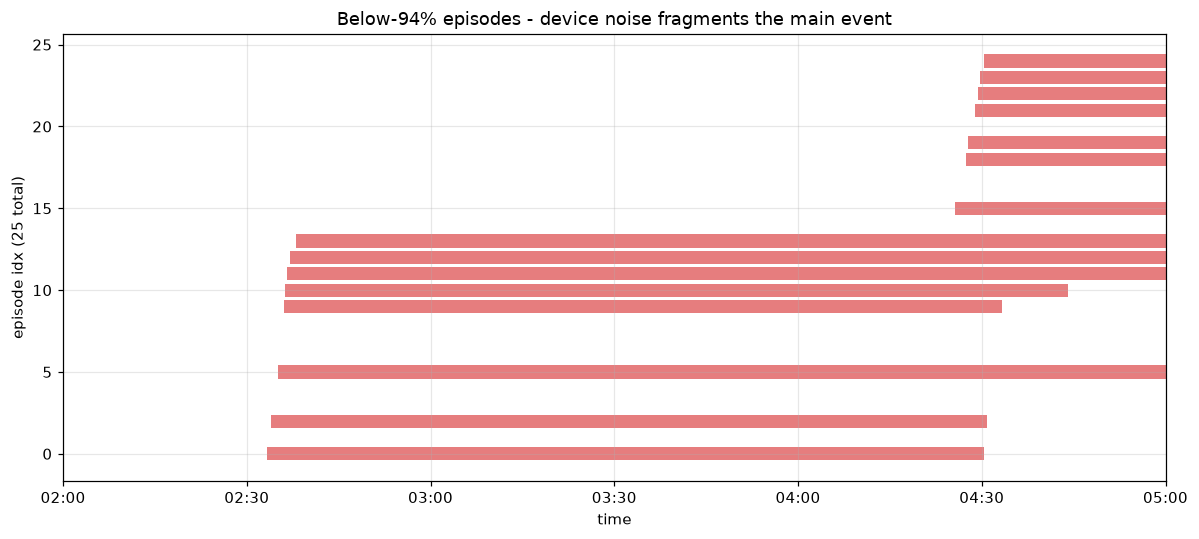

In [4]:
episodes = run_lesson(lesson("a1_desaturation_episodes")).copy()
episodes["start"] = tz_free(episodes["episode_start"])
episodes["end"] = tz_free(episodes["episode_end"])
episodes = episodes.sort_values("start").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 5))
for i in range(len(episodes)):
    minutes = (episodes["end"].iloc[i] - episodes["start"].iloc[i]).total_seconds() / 60
    ax.barh(i, minutes, left=episodes["start"].iloc[i], height=0.8,
            color="#d62728", alpha=0.6)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time")
ax.set_ylabel(f"episode idx ({len(episodes)} total)")
ax.set_title("Below-94% episodes - device noise fragments the main event")
ax.set_xlim(pd.Timestamp("2026-01-01 02:00:00"), pd.Timestamp("2026-01-01 05:00:00"))
plt.tight_layout()
plt.show()


In [5]:
a1_90 = load_lesson_sql(lesson("a1_desaturation_episodes")).replace("spo2_pct < 94", "spo2_pct < 90")
deep = run_live(a1_90)
print(f"threshold 90% -> {len(deep)} episodes, "
      f"{int(deep['readings'].sum())} low readings")
display(deep.head(10))


threshold 90% -> 27 episodes, 787 low readings


,episode_start,episode_end,duration_seconds,readings,lowest_spo2,avg_spo2
0,2026-01-01 02:54:40.305120+00:00,2026-01-01 02:54:40.305120+00:00,0,1,89.0,89.0
1,2026-01-01 02:56:45.285990+00:00,2026-01-01 02:56:45.285990+00:00,0,1,89.0,89.0
2,2026-01-01 02:57:00.304355+00:00,2026-01-01 02:57:10.572071+00:00,10,3,89.0,89.0
3,2026-01-01 02:57:20.526773+00:00,2026-01-01 02:57:20.526773+00:00,0,1,89.0,89.0
4,2026-01-01 02:57:40.493450+00:00,2026-01-01 02:58:15.319765+00:00,34,8,89.0,89.0
5,2026-01-01 02:58:25.419928+00:00,2026-01-01 02:58:25.419928+00:00,0,1,89.0,89.0
6,2026-01-01 02:58:50.220244+00:00,2026-01-01 02:59:00.454825+00:00,10,3,89.0,89.0
7,2026-01-01 02:59:15.506215+00:00,2026-01-01 03:11:15.369361+00:00,719,144,88.0,89.0
8,2026-01-01 03:11:25.593704+00:00,2026-01-01 03:19:40.303244+00:00,494,100,88.0,89.0
9,2026-01-01 03:19:50.258183+00:00,2026-01-01 03:24:45.570494+00:00,295,58,88.0,88.9


**Try it.** That cell re-ran the SAME query with a **90% threshold** by
splicing the lesson text. With the deeper threshold the trace still fragments,
but far less — the crossing region is smaller. Episode counts must always be
reported *together with the threshold that produced them*.

### A2 — "Turn hundreds of alarm ticks into 2 alarm events"

An alarm that rings below 90% SpO2 fires nearly every 5 seconds during Naomi's
desaturation — useless for a tired clinician. Rule: collapse a continuous burst
into ONE event, and start a NEW event only after **2 minutes of quiet**. How
many real alarms fired, and what did each cover?

*What this teaches:* **sessionization** — filter to the hits, measure the gap to
the previous hit with `LAG()`, then a running `SUM()` that seeds a new session
whenever the gap >= 120 seconds.


**1. Read the SQL for `a2_alarm_sessions`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [6]:
show_sql("a2_alarm_sessions")

-- ============================================================================
-- Lesson A2 — "Turn 900 alarm ticks into 4 alarm events (sessionization)"
--
-- Business question
--   A device alarm that fires below 90% SpO2 would ring nearly every 5
--   seconds while Naomi is desaturating -- useless for a tired clinician.
--   The alarm system should collapse a continuous burst into ONE event, and
--   start a NEW event only after 2 minutes of quiet. How many real alarms
--   actually fired, and what did each one cover?
--
-- Concepts taught
--   * Sessionization / event burst collapsing -- window functions at their
--     most business-valuable
--   * Filtering down to only the "alarm" readings first
--   * LAG() on the filtered stream to measure the gap to the previous alarm
--   * A running SUM() that seeds a new session whenever the gap resets
--     (>= 120 seconds of quiet), otherwise continues the current one
--
-- Read the WITH chain top to bottom: hits (alarm ticks) -> gaps 

**2. Run it against the lakehouse.**

In [7]:
df = run_lesson(lesson("a2_alarm_sessions"))
display(df)

,alarm_started,alarm_ended,lowest_spo2,avg_spo2,alert_readings
0,2026-01-01 02:54:40.305120+00:00,2026-01-01 02:54:40.305120+00:00,89.0,89.0,1
1,2026-01-01 02:56:45.285990+00:00,2026-01-01 04:05:45.489483+00:00,87.0,88.9,786


**Reading the result.** Two alarms fired that night:

1. **02:54:40** — a *single* reading at 89%. One tick, then nothing for 2+
   minutes. Almost certainly the sensor spike / onset blip.
2. **02:56:45 → 04:05:45** — the *real* event: 786 readings, lowest 87,
   average 88.9.

The burst of raw alarm ticks became **one** reportable alarm event.


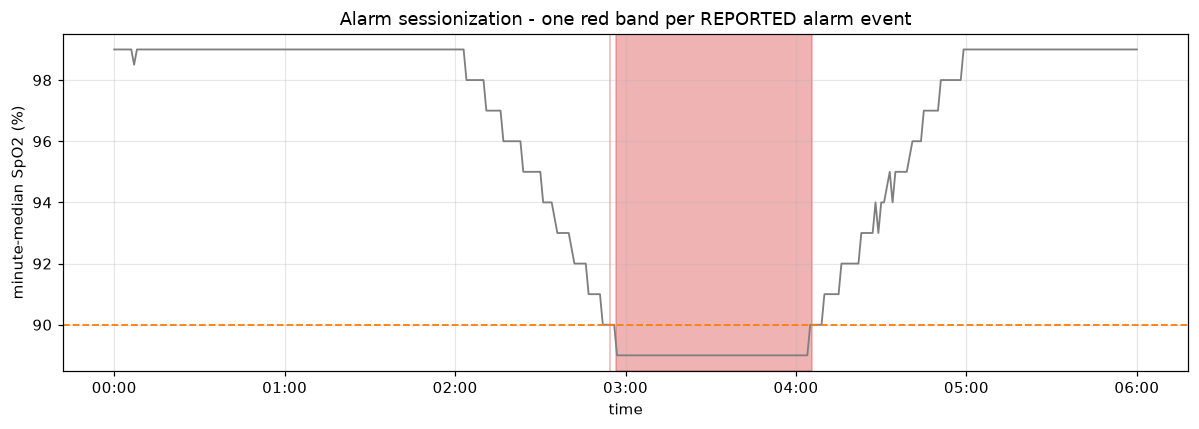

In [8]:
sessions = run_lesson(lesson("a2_alarm_sessions")).copy()
starts = tz_free(sessions["alarm_started"])
ends = tz_free(sessions["alarm_ended"])

trace = run_live(
    "SELECT event_time, spo2_pct FROM lake.lakehouse.vitals "
    f"WHERE patient_id = '{NAOMI}' ORDER BY event_time"
)
trace["t"] = tz_free(trace["event_time"])
minute = trace.set_index("t")["spo2_pct"].resample("1min").median()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(minute.index, minute.values, color="#7f7f7f", lw=1.2)
for i in range(len(sessions)):
    ax.axvspan(starts.iloc[i], ends.iloc[i], color="#d62728", alpha=0.35)
ax.axhline(90, color="#ff7f0e", ls="--", lw=1.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("time")
ax.set_ylabel("minute-median SpO2 (%)")
ax.set_title("Alarm sessionization - one red band per REPORTED alarm event")
plt.tight_layout()
plt.show()


**Reading this chart.** Each red band is one alarm *event* — the whole
desaturation — while "how many readings were low?" would have screamed
*hundreds*. The grey trace between bands is the "quiet" a sessionizer required
before starting a new session.

### A3 — "Can we trust the monitor? Audit device readings vs the truth"

The bedside monitor is an instrument (Milestone 8): it adds noise, rounds
values, occasionally drops a reading. We seeded `lake.lakehouse.vitals_truth` —
the *exact* simulated physiology for every tick — precisely so fidelity can be
MEASURED. How far is observed telemetry from true physiology, minute by minute?

*What this teaches:* resampling with `date_trunc('minute', ...)` + **median**
(robust to the spikes a mean would drag around), a clean cross-table JOIN on
shared `(minute, patient)` buckets, and a grouped aggregate computing **bias**
(mean signed error) and **MAE** (mean absolute error).


**1. Read the SQL for `a3_observed_vs_truth`** — the file comments explain the business question and how the query is assembled, piece by piece.

In [9]:
show_sql("a3_observed_vs_truth")

-- ============================================================================
-- Lesson A3 — "Can we trust the monitor? Benchmark device readings
--              against the true trace"
--
-- Business question
--   The bedside monitor is a measurement instrument (Milestone 8): it adds
--   noise, rounds values, occasionally drops a reading. During one critical
--   stretch its SpO2 was 2 points lower than the true physiology. How big
--   is the observed-vs-truth error in practice, minute by minute?
--
-- Concepts taught
--   * WHY we also loaded a truth table: lake.lakehouse.vitals_truth holds
--     the exact simulated physiology for every tick, so fidelity can be
--     MEASURED (the same alignment idea as the Milestone 9 notebook)
--   * RESAMPLING to a coarser grain with date_trunc + median (the median
--     is robust to the occasional spike that a mean would drag around)
--   * A clean cross-catalog join: observed (vitals) and truth
--     (vitals_truth) meeting on their share

**2. Run it against the lakehouse.**

In [10]:
df = run_lesson(lesson("a3_observed_vs_truth"))
display(df)

,minute_bucket,observed_spo2,true_spo2,bias,abs_error
0,2026-01-01 00:00:00+00:00,99.0,98.899943,0.100,0.100
1,2026-01-01 00:01:00+00:00,99.0,98.807606,0.192,0.192
2,2026-01-01 00:02:00+00:00,99.0,98.939644,0.060,0.060
3,2026-01-01 00:03:00+00:00,99.0,99.017053,-0.017,0.017
4,2026-01-01 00:04:00+00:00,99.0,98.985992,0.014,0.014
...,...,...,...,...,...
356,2026-01-01 05:56:00+00:00,99.0,99.126660,-0.127,0.127
357,2026-01-01 05:57:00+00:00,99.0,99.204855,-0.205,0.205
358,2026-01-01 05:58:00+00:00,99.0,99.314597,-0.315,0.315
359,2026-01-01 05:59:00+00:00,99.0,99.189407,-0.189,0.189


**Reading the result.** One row per minute for Naomi's stay, with observed
minute-median, true minute-median and the error. Overall the bias ≈ 0 (the
monitor is not systematically lying) but per-minute errors are non-zero,
driven by the dropout windows and the sensor spikes. The grand bottom line:


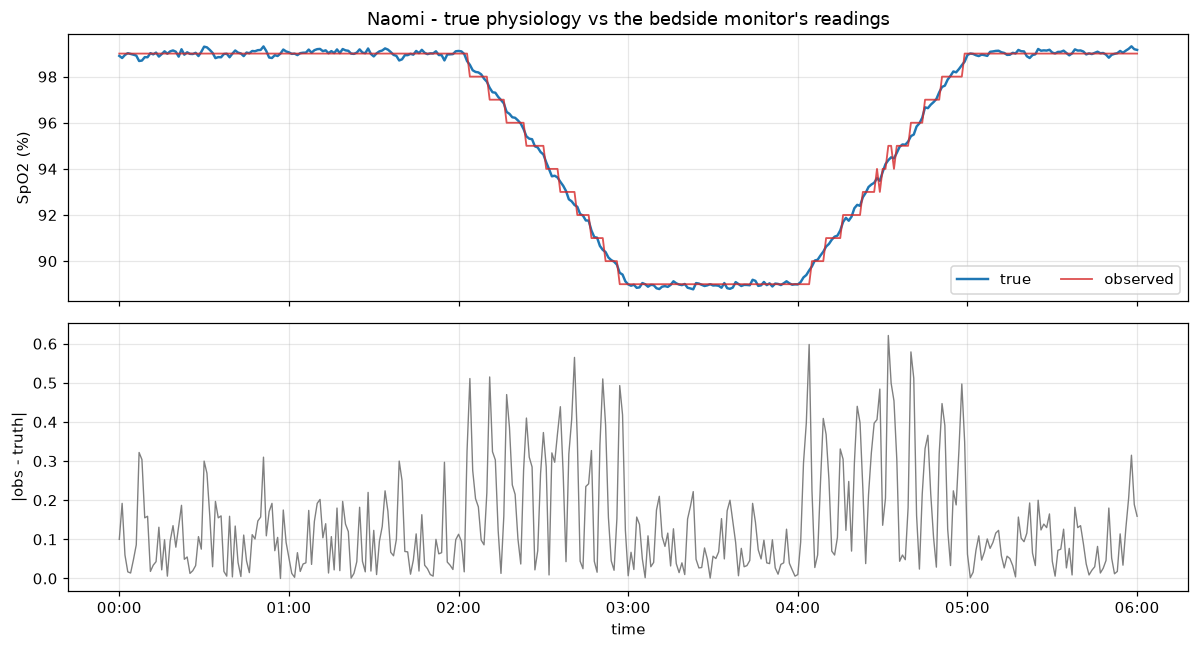

MAE over 361 minutes: 0.142 points (worst minute: 0.621)


In [11]:
audit = run_lesson(lesson("a3_observed_vs_truth")).copy()
audit["t"] = tz_free(audit["minute_bucket"])

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax_top.plot(audit["t"], audit["true_spo2"], color="#1f77b4", lw=1.6, label="true")
ax_top.plot(audit["t"], audit["observed_spo2"], color="#d62728", lw=1.2,
            alpha=0.8, label="observed")
ax_top.set_ylabel("SpO2 (%)")
ax_top.set_title("Naomi - true physiology vs the bedside monitor's readings")
ax_top.legend(loc="lower right", ncol=2)

ax_bot.plot(audit["t"], audit["abs_error"], color="grey", lw=0.9)
ax_bot.set_ylabel("|obs - truth|")
ax_bot.set_xlabel("time")
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

stats = audit["abs_error"].describe()
print(f"MAE over {len(audit)} minutes: {stats['mean']:.3f} points "
      f"(worst minute: {stats['max']:.3f})")


**What you now know.** You went from "who is on the ward?" (a JOIN) to
"audit a sensor against ground truth" (a cross-catalog, resampled,
window-tolerant join). The full arc of the series:

* `SELECT`/`JOIN`/`ORDER BY` — *shape* the data
* `date_trunc` + `GROUP BY` — *bucket* the data
* CTEs — *compose* the query
* `LAG`/`LEAD` — *before / after*
* moving averages — *sustained trends*
* `RANK`/`NTILE` — *rank & distribution*
* gap-and-islands — *episodes*
* sessionization — *events from streams*

**Final exercises** (in `sql/dql/advanced/`):

1. `a1_desaturation_episodes.sql` — add a heal rule: only start a new island
   when the gap to the previous island is >= 60 s. (Hint: `LAG()` on the
   island-start rows, then the classic running `SUM`.)
2. `a2_alarm_sessions.sql` — change the quiet window from `120` to `30`
   seconds. The two alarms become three or more: shorter quiet → more
   fragments. That is the cost/benefit knob of every paging policy.
3. `a3_observed_vs_truth.sql` — switch to Cole's patient id. Which channel
   really needs the audit?
